<div style="background-color: lightblue; color: black; border: 2px solid black; 
padding: 15px 25px; border-radius: 8px; margin: 10px 0px;">

  <h2 style="color: black; margin: 0px 0px 10px 0px;">
   Rain gauge optimisation
  </h2>

  <hr style="border: 1px solid black; margin: 10px 0px;">

  <p>This code works on defining optimal locations for placements of new rain gauges in the Upper Severn catchment. The placement of the gauges aims to optimise the accuracy with which rainfall over the catchment can be predicted. </p>

  <p><strong>The following data is available:</strong></p>
  <ul>
    <li> 1km HAD-UK gridded annual (?) rainfall data </li>
    <li> Rain gauge data from 10? existing rain gauges</li>
    <li> 30m (?) DEM data: from which slope and aspect can be derived. These are then aggregated to 1km </li>      
  </ul>
<!-- 
  <div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
    <strong>NB:</strong> The threshold for an "unphysical" value is 
    currently set at <strong>150mm/hr</strong> — selected relatively 
    arbitrarily and may need review.
  </div> -->

</div>

In [32]:
import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path
import xarray as xr
import matplotlib.pyplot as plt

data_dir = "/scratch/hydro4/users/kv25483/FDRI/Rain_gauge_optimisation/Data/"
catchment_Dolwen = gpd.read_file(data_dir + "54080/54080.shp")

### Get rain gauge data

In [47]:
# Load rain gauge metadata
rain_meta_cmd = pd.read_csv(data_dir + "rain_meta_for_CMD.csv")

# Convert to GeoDataFrame (BNG coordinates)
rain_meta_sf = gpd.GeoDataFrame(rain_meta_cmd, geometry=gpd.points_from_xy(rain_meta_cmd["x_2"], rain_meta_cmd["y_2"]),
                                crs="EPSG:27700")

existing_gauges = rain_meta_sf.to_crs(rainfall_gdf_merged.crs)
existing_coords = np.array([(g.x, g.y) for g in existing_gauges.geometry])
existing_coords = np.asarray(existing_coords)

rain_meta_sf

,station_name,station_id,lon,lat,x,y,x_2,y_2,elevation_m,elevation_m_2,elevation_1m,geometry
0,DOLYDD,1152.0,-3.661117,52.500357,287337.0,290459.0,287337.518,290457.408,299.235000,299.325828,299.092,POINT (287337.518 290457.408)
1,NANTGWYNMAIN,1408.0,-3.500905,52.380125,297934.0,276848.0,297934.427,276846.549,297.873003,297.870419,298.000,POINT (297934.427 276846.549)
2,Carreg_2000,NaN,-3.726067,52.482174,NaN,NaN,282880.590,288538.431,NaN,576.075517,576.000,POINT (282880.59 288538.431)
3,Tan2,NaN,-3.705166,52.474825,NaN,NaN,284280.550,287687.340,NaN,352.008129,352.000,POINT (284280.55 287687.34)
4,Clywedog,NaN,-3.606000,52.470000,NaN,NaN,291003.558,286996.319,NaN,316.186793,316.942,POINT (291003.558 286996.319)
5,Garth-fawr,NaN,-3.477000,52.400000,NaN,NaN,299606.620,279023.643,NaN,364.992961,366.000,POINT (299606.62 279023.643)
6,Llanidloes,NaN,-3.547000,52.442000,NaN,NaN,294944.369,283794.594,NaN,177.003153,177.000,POINT (294944.369 283794.594)
7,Foel_fadien,NaN,NaN,NaN,NaN,NaN,283398.000,295527.000,NaN,530.000000,530.000,POINT (283398 295527)


### Get gridded rainfall data

In [25]:
# rainfall_gdf_merged = gpd.read_file(data_dir+ "Derived/rainfall_gdf_merged.gpkg")

HAD_names = sorted(Path(data_dir + "HAD_rainfall_annual/").glob("*.nc"))
HAD_layers = [xr.open_dataset(f) for f in HAD_names]
HAD_ann = xr.concat([ds['rainfall'] for ds in HAD_layers], dim="time")

HAD_ann = HAD_ann.rio.write_crs("EPSG:27700")
HAD_Dolwen_ppn = HAD_ann.rio.clip(catchment_Dolwen.geometry, crs=catchment_Dolwen.crs,drop=True, all_touched=True)
HAD_Dolwen_ppn_mean = HAD_Dolwen_ppn.mean(dim="time")

In [22]:
# for i, (val, coord) in enumerate(zip(gauge_rainfall, existing_coords)):
#     print(f"Gauge {i}: coords {coord}, rainfall {val:.1f} mm")

In [26]:
x_coords = HAD_Dolwen_ppn_mean.projection_x_coordinate.values
y_coords = HAD_Dolwen_ppn_mean.projection_y_coordinate.values

xx, yy = np.meshgrid(x_coords, y_coords)
x_flat = xx.flatten()
y_flat = yy.flatten()
rainfall_flat = HAD_Dolwen_ppn_mean.values.flatten()

# Remove NaNs
valid = ~np.isnan(rainfall_flat)
x_flat = x_flat[valid]
y_flat = y_flat[valid]
rainfall_flat = rainfall_flat[valid]

#### Fit a variogram using HAD-UK data across the whole catchment

In [29]:
from scipy.spatial.distance import pdist, squareform
from scipy.optimize import curve_fit

# Calculate pairwise distances between all HAD-UK points
coords = np.column_stack([x_flat, y_flat])
distances = pdist(coords)
# Calculate pairwise squared differences in rainfall
rainfall_diff = pdist(rainfall_flat.reshape(-1, 1), 
                      metric=lambda u, v: 0.5 * (u - v) ** 2)

# Bin the semivariances by distance
n_bins = 20
max_dist = 50000  # 50km - adjust based on catchment size
bin_edges = np.linspace(0, max_dist, n_bins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

gamma = np.zeros(n_bins)
counts = np.zeros(n_bins)

for i in range(n_bins):
    mask = (distances >= bin_edges[i]) & (distances < bin_edges[i+1])
    if mask.sum() > 0:
        gamma[i] = rainfall_diff[mask].mean()
        counts[i] = mask.sum()

# Remove empty bins
valid_bins = counts > 0
bin_centers = bin_centers[valid_bins]
gamma = gamma[valid_bins]

# Define exponential variogram model
# nugget = variance at zero distance (measurement error)
# sill = plateau variance
# range_ = distance at which correlation dies out
def exponential_variogram(h, nugget, sill, range_):
    return nugget + (sill - nugget) * (1 - np.exp(-h / range_))

# Fit to empirical variogram
# Initial guesses for parameters
p0 = [gamma.min(),           # nugget
    gamma.max(),           # sill  
    max_dist / 3 ]          # range

params, _ = curve_fit(exponential_variogram, bin_centers, gamma, p0=p0,bounds=(0, np.inf))

nugget, sill, range_ = params
print(f"Nugget: {nugget:.1f}")
print(f"Sill: {sill:.1f}")
print(f"Range: {range_:.1f} m")

def kriging_variance(pred_points, cond_points, nugget, sill, range_):
    """
    Calculate kriging variance at prediction points
    given conditioning points (existing gauges)
    """
    n = len(cond_points)
    variances = np.zeros(len(pred_points))
    
    # Build covariance matrix between conditioning points
    C = np.zeros((n + 1, n + 1))
    for i in range(n):
        for j in range(n):
            h = np.linalg.norm(cond_points[i] - cond_points[j])
            # Covariance = sill - variogram
            C[i, j] = sill - exponential_variogram(h, nugget, sill, range_)
    # Add Lagrange multiplier row/col for ordinary kriging
    C[:n, n] = 1
    C[n, :n] = 1
    C[n, n] = 0
    
    # For each prediction point
    for k, pred in enumerate(pred_points):
        # Build covariance vector between pred point and gauges
        c = np.zeros(n + 1)
        for i in range(n):
            h = np.linalg.norm(pred - cond_points[i])
            c[i] = sill - exponential_variogram(h, nugget, sill, range_)
        c[n] = 1  # Lagrange multiplier
        
        # Solve kriging system
        try:
            weights = np.linalg.solve(C, c)
            # Kriging variance
            variances[k] = sill - np.dot(weights, c)
        except np.linalg.LinAlgError:
            variances[k] = np.nan
            
    return variances

# Calculate variance at all HAD-UK grid cells
pred_points = np.column_stack([x_flat, y_flat])
cond_points = existing_coords

variance = kriging_variance(pred_points, cond_points, nugget, sill, range_)

# Create a dataframe of coordinates and variance values
variance_df = pd.DataFrame({ 'x': x_flat,'y': y_flat,'kriging_variance': variance})

# Round coordinates to match your grid (avoids floating point mismatches)
variance_df['x'] = variance_df['x'].round(-2)  # round to nearest 100m
variance_df['y'] = variance_df['y'].round(-2)

# Do the same for your grid centroids
rainfall_gdf_merged['x_centroid'] = rainfall_gdf_merged.geometry.centroid.x.round(-2)
rainfall_gdf_merged['y_centroid'] = rainfall_gdf_merged.geometry.centroid.y.round(-2)

# Merge variance onto grid
rainfall_gdf_merged = rainfall_gdf_merged.merge(variance_df,left_on=['x_centroid', 'y_centroid'],right_on=['x', 'y'],
                                                how='left')


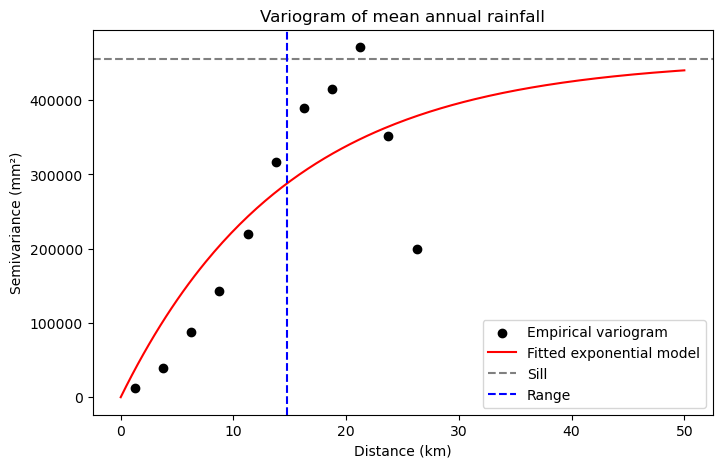

In [33]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(bin_centers/1000, gamma, label='Empirical variogram', 
           color='black', zorder=5)
h_plot = np.linspace(0, max_dist, 200)
ax.plot(h_plot/1000, 
        exponential_variogram(h_plot, nugget, sill, range_),
        color='red', label='Fitted exponential model')
ax.axhline(sill, color='grey', linestyle='--', label='Sill')
ax.axvline(range_/1000, color='blue', linestyle='--', label='Range')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Semivariance (mm²)')
ax.set_title('Variogram of mean annual rainfall')
ax.legend()
plt.show()

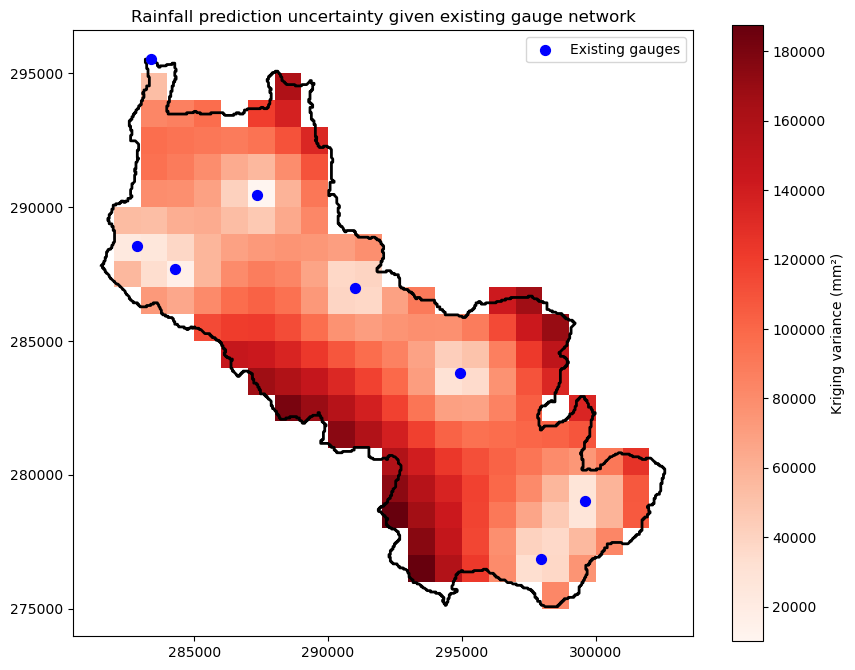

In [38]:
# Plot as grid cells
fig, ax = plt.subplots(figsize=(10, 8))
rainfall_gdf_merged.plot(column='kriging_variance',cmap='Reds',legend=True,ax=ax,
                         legend_kwds={'label': 'Kriging variance (mm²)'})

existing_gauges.plot( ax=ax, color='blue', markersize=50, label='Existing gauges', zorder=5)
catchment_Dolwen.boundary.plot(ax=ax,color='black',linewidth=2)

ax.set_title('Rainfall prediction uncertainty given existing gauge network')
plt.legend()
plt.show()

In [49]:
gauge_rainfall

array([1969.60052116, 1410.05261377, 2905.09448423, 2461.29904364,
       1717.6304151 , 1230.73176895, 1295.25672508, 1935.92744785])

In [39]:
import gstools as gs

# Get all HAD-UK cell centroids and rainfall values within catchment
# haduk_coords = np.array([(g.x, g.y) for g in rainfall_gdf_merged.geometry])

haduk_coords = np.array([
    (geom.centroid.x, geom.centroid.y)
    for geom in rainfall_gdf_merged.geometry])

haduk_rainfall = rainfall_gdf_merged['rainfall'].values

# Fit variogram to HAD-UK data
x, y = haduk_coords[:, 0], haduk_coords[:, 1]

# Fit an exponential variogram model
bin_center, gamma = gs.vario_estimate( (x, y),haduk_rainfall,bin_edges=np.linspace(0, 50000, 20))

# Fit model to empirical variogram
fit_model = gs.Exponential(dim=2)
fit_model.fit_variogram(bin_center, gamma)
print(fit_model)

# Get HAD-UK rainfall values at existing gauge locations
from rasterstats import point_query

# Extract mean annual rainfall at each existing gauge location
gauge_x = xr.DataArray(existing_coords[:, 0], dims="points")
gauge_y = xr.DataArray(existing_coords[:, 1], dims="points")
gauge_rainfall = HAD_Dolwen_ppn_mean.sel(projection_x_coordinate=gauge_x,projection_y_coordinate=gauge_y,
                                         method="nearest").values

# Set up universal kriging conditioned on existing gauges
krige = gs.krige.Universal(model=fit_model, cond_pos=(existing_coords[:, 0], existing_coords[:, 1]),
    cond_val=gauge_rainfall,drift_functions="linear")

# Calculate variance at every HAD-UK grid cell centroid
grid_x = haduk_coords[:, 0]
grid_y = haduk_coords[:, 1]

_, variance = krige((grid_x, grid_y), return_var=True)

# Add variance back to your GeoDataFrame
rainfall_gdf_merged['kriging_variance'] = variance

Exponential(dim=2, var=2.38e-26, len_scale=1e+05, nugget=1.38e+04)


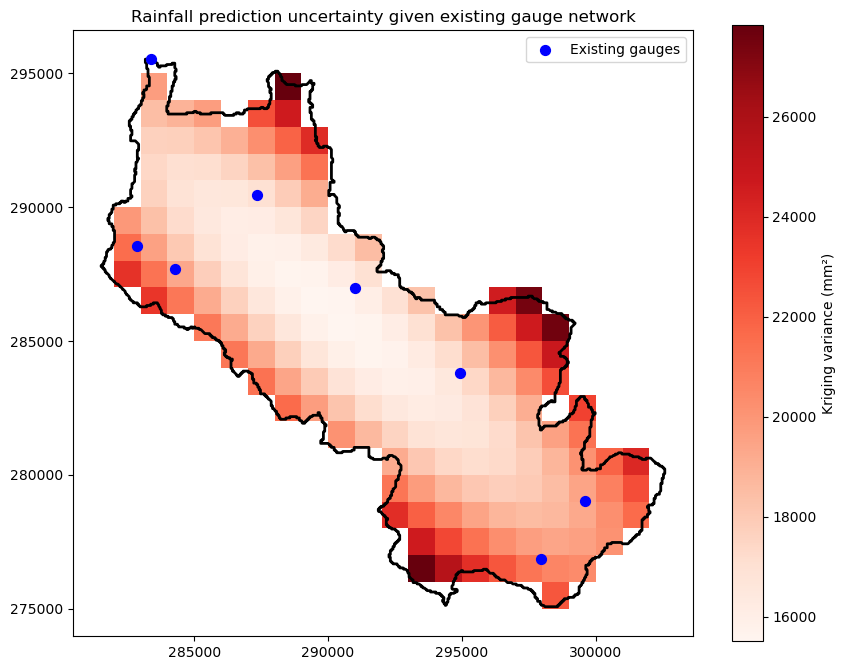

In [44]:
fig, ax = plt.subplots(figsize=(10, 8))
rainfall_gdf_merged.plot(column='kriging_variance',cmap='Reds',legend=True,ax=ax,
                         legend_kwds={'label': 'Kriging variance (mm²)'})
existing_gauges.plot(ax=ax, color='blue', markersize=50, 
                     label='Existing gauges', zorder=5)
catchment_Dolwen.plot(ax=ax, color='none', 
                        edgecolor='black', linewidth=2)
ax.set_title('Rainfall prediction uncertainty given existing gauge network')
plt.legend()
plt.show()

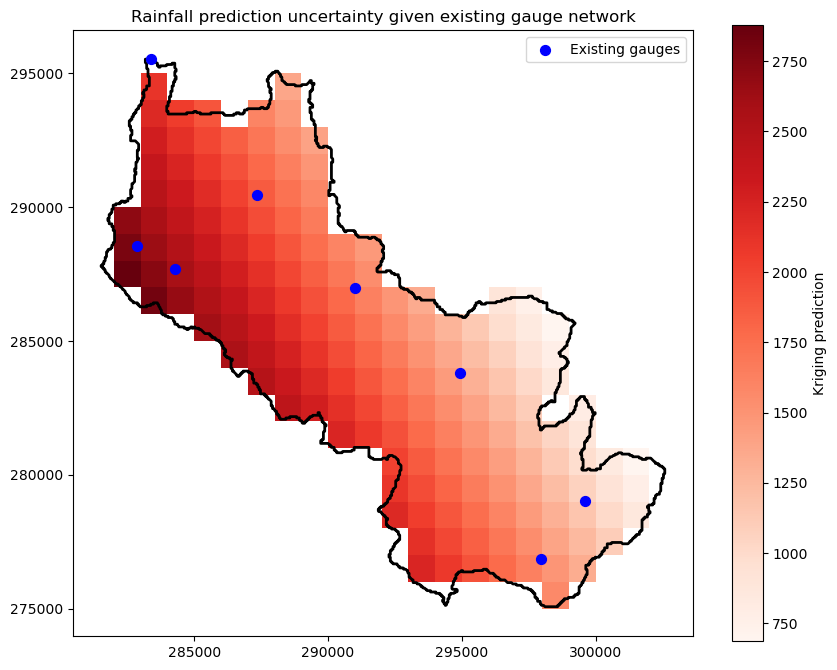

In [48]:
fig, ax = plt.subplots(figsize=(10, 8))
rainfall_gdf_merged.plot(column='kriging_prediction',cmap='Reds',legend=True,ax=ax,
                         legend_kwds={'label': 'Kriging prediction'})
existing_gauges.plot(ax=ax, color='blue', markersize=50, 
                     label='Existing gauges', zorder=5)
catchment_Dolwen.plot(ax=ax, color='none', 
                        edgecolor='black', linewidth=2)
ax.set_title('Rainfall prediction uncertainty given existing gauge network')
plt.legend()
plt.show()

In [45]:
prediction, variance = krige((grid_x, grid_y), return_var=True)
rainfall_gdf_merged['kriging_prediction'] = prediction